In [ ]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [ ]:
tel=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MINI PROJECT/PdM_telemetry.csv')
err=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MINI PROJECT/PdM_errors.csv')
fail=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MINI PROJECT/PdM_failures.csv')
maint=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MINI PROJECT/PdM_maint.csv')
Machine=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MINI PROJECT/PdM_machines.csv')

In [ ]:
tel["newdate"]=tel['datetime']
err["newdate"]=err['datetime']
fail["newdate"]=fail['datetime']
maint["newdate"]=maint['datetime']

In [ ]:
tel["newdate"] = (
    tel["newdate"]
    .str.replace("-", "")
    .str.replace(":", "")
    .str.replace(" ", "")
    .str.replace("/", "")
)
err["newdate"] = (
    err["newdate"]
    .str.replace("-", "")
    .str.replace(":", "")
    .str.replace(" ", "")
    .str.replace("/", "")
)
fail["newdate"] = (
    fail["newdate"]
    .str.replace("-", "")
    .str.replace(":", "")
    .str.replace(" ", "")
    .str.replace("/", "")
)
maint["newdate"] = (
    maint["newdate"]
    .str.replace("-", "")
    .str.replace(":", "")
    .str.replace(" ", "")
    .str.replace("/", "")
)

In [ ]:
tel["unique_id"] = (
    tel["machineID"].astype(str) + "-" +
    tel["newdate"].astype(str)
)
err["unique_id"] = (
    err["machineID"].astype(str) + "-" +
    err["newdate"].astype(str)
)
fail["unique_id"] = (
    fail["machineID"].astype(str) + "-" +
    fail["newdate"].astype(str)
)
maint["unique_id"] = (
    maint["machineID"].astype(str) + "-" +
    maint["newdate"].astype(str)
)


In [ ]:
df = tel.merge(
    err[['unique_id', 'errorID']],
    on='unique_id',
    how='left'
)

In [ ]:
df = df.merge(
    fail[['unique_id', 'failure']],
    on='unique_id',
    how='left'
)

In [ ]:
df = df.merge(
    maint[['unique_id', 'comp']],
    on='unique_id',
    how='left'
)

In [ ]:
df = df.merge(
    Machine[['machineID', 'model', 'age']],
    on='machineID',
    how='left'
)

In [ ]:
df = df.drop(columns=['newdate', 'unique_id'])

In [ ]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,errorID,failure,comp,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,NaN,NaN,NaN,model3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,NaN,NaN,NaN,model3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,NaN,NaN,NaN,model3,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,NaN,NaN,NaN,model3,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,NaN,NaN,NaN,model3,18


In [ ]:
df.shape

(877209, 11)

In [ ]:
df.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'errorID', 'failure', 'comp', 'model', 'age'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 877209 entries, 0 to 877208
Data columns (total 11 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   877209 non-null  object 
 1   machineID  877209 non-null  int64  
 2   volt       877209 non-null  float64
 3   rotate     877209 non-null  float64
 4   pressure   877209 non-null  float64
 5   vibration  877209 non-null  float64
 6   errorID    3924 non-null    object 
 7   failure    1122 non-null    object 
 8   comp       2968 non-null    object 
 9   model      877209 non-null  object 
 10  age        877209 non-null  int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 73.6+ MB


In [ ]:
df.describe()

,machineID,volt,rotate,pressure,vibration,age
count,877209.000000,877209.000000,877209.000000,877209.000000,877209.000000,877209.000000
mean,50.498446,170.780942,446.570735,100.861433,40.386459,11.330280
std,28.866697,15.511268,52.698963,11.052195,5.371894,5.827535
min,1.000000,97.333604,138.432075,51.237106,14.877054,0.000000
25%,25.000000,160.305918,412.265479,93.499116,36.777911,7.000000
50%,50.000000,170.609301,447.537538,100.426820,40.238339,12.000000
75%,75.000000,181.008303,482.157025,107.557338,43.786484,16.000000
max,100.000000,255.124717,695.020984,185.951998,76.791072,20.000000


In [ ]:
df.isnull().sum()

,0
datetime,0
machineID,0
volt,0
rotate,0
pressure,0
vibration,0
errorID,873285
failure,876087
comp,874241
model,0


In [ ]:
df['errorID'] = df['errorID'].fillna('NoError')
df['failure'] = df['failure'].fillna('NoFailure')
df['comp'] = df['comp'].fillna('NoComponent')
df.isnull().sum()

,0
datetime,0
machineID,0
volt,0
rotate,0
pressure,0
vibration,0
errorID,0
failure,0
comp,0
model,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [ ]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

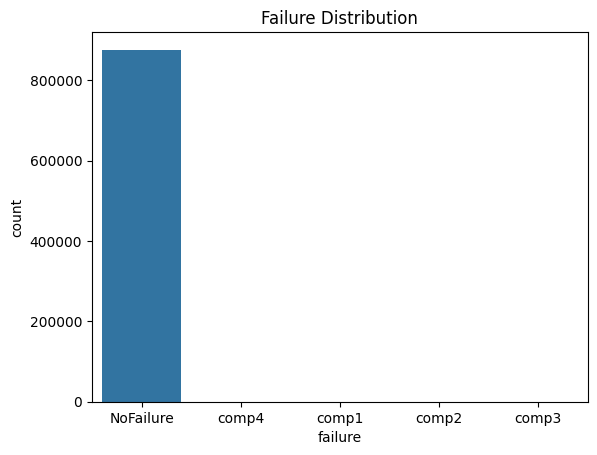

In [ ]:
sns.countplot(x='failure', data=df)
plt.title('Failure Distribution')
plt.show()

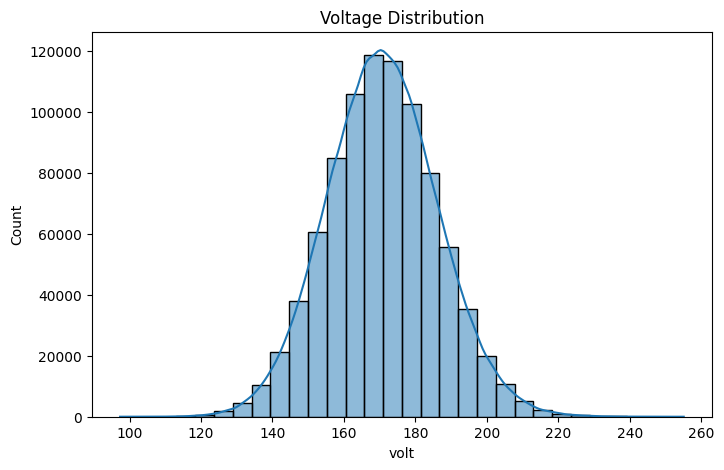

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['volt'], bins=30, kde=True)
plt.title('Voltage Distribution')
plt.show()

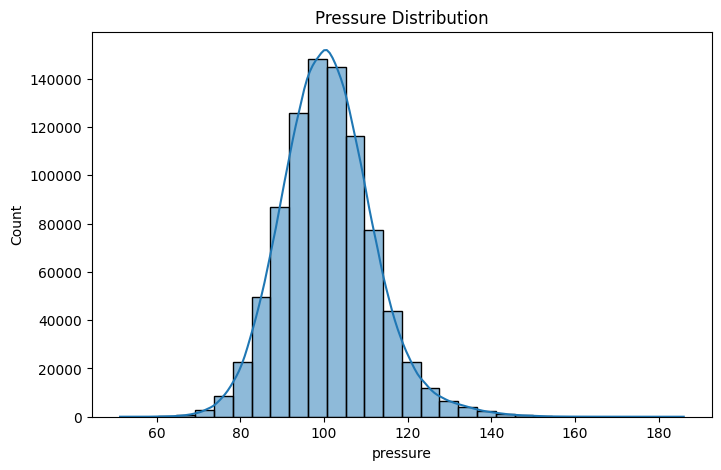

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['pressure'], bins=30, kde=True)
plt.title('Pressure Distribution')
plt.show()

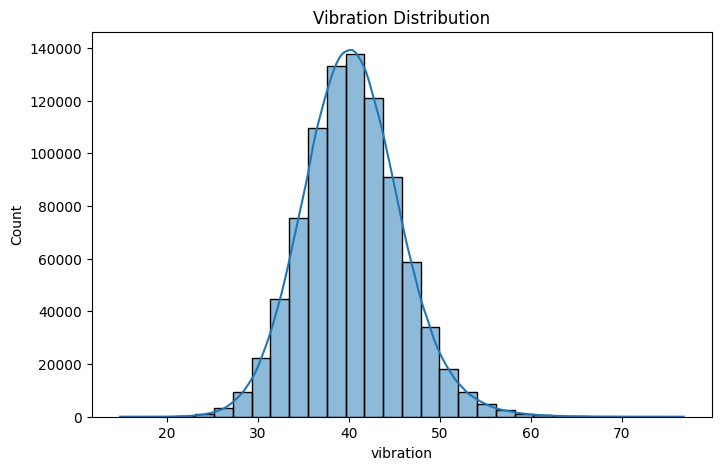

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['vibration'], bins=30, kde=True)
plt.title('Vibration Distribution')
plt.show()

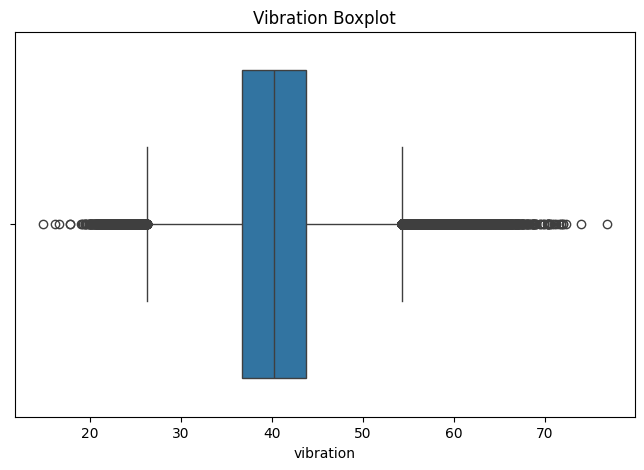

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['vibration'])
plt.title('Vibration Boxplot')
plt.show()

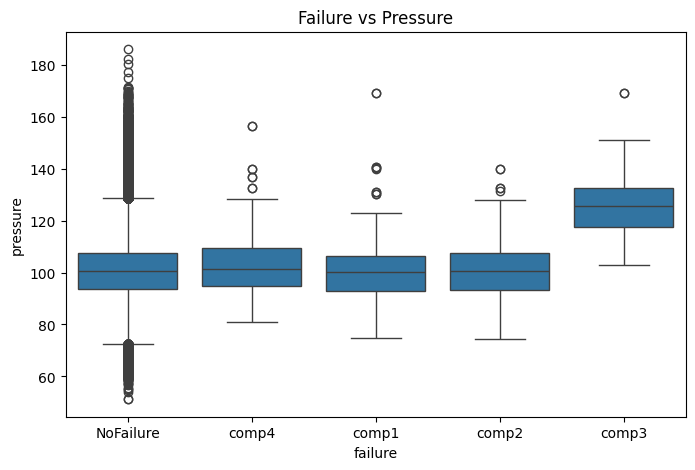

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='failure', y='pressure', data=df)
plt.title('Failure vs Pressure')
plt.show()

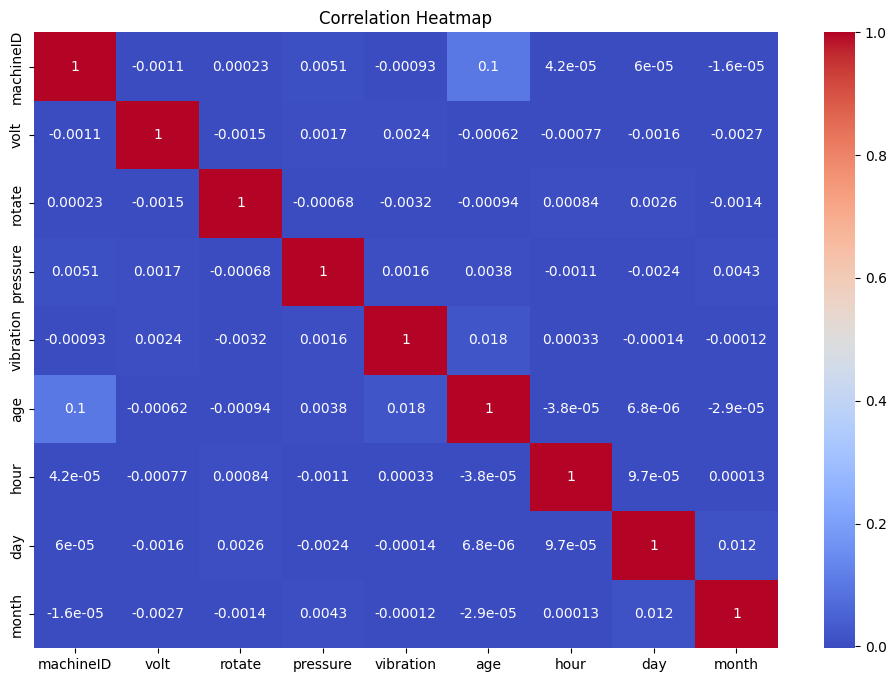

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

# Correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Convert target variable

df['failure'] = np.where(df['failure']=='NoFailure',0,1)

In [ ]:
# One-hot encoding

df = pd.get_dummies(df, columns=['errorID','comp','model'], drop_first=True)

In [ ]:
# Drop unnecessary columns

df = df.drop(columns=['datetime'])

In [ ]:
# Features

X = df.drop(columns=['failure'])

# Target

y = df['failure']

In [ ]:
#smote

!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X, y)
print(y.value_counts())

print(y_smote.value_counts())

failure
0    876087
1      1122
Name: count, dtype: int64
failure
0    876087
1    876087
Name: count, dtype: int64


In [ ]:
# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X_smote,
    y_smote,
    test_size=0.2,
    random_state=42,
    stratify=y_smote
)

In [ ]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Logistic Regression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
print('Logistic Regression Accuracy:', accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9988071967697291
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       1.00      1.00      1.00    175217

    accuracy                           1.00    350435
   macro avg       1.00      1.00      1.00    350435
weighted avg       1.00      1.00      1.00    350435



In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9995890821407679
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       1.00      1.00      1.00    175217

    accuracy                           1.00    350435
   macro avg       1.00      1.00      1.00    350435
weighted avg       1.00      1.00      1.00    350435



In [ ]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9996718364318633
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       1.00      1.00      1.00    175217

    accuracy                           1.00    350435
   macro avg       1.00      1.00      1.00    350435
weighted avg       1.00      1.00      1.00    350435



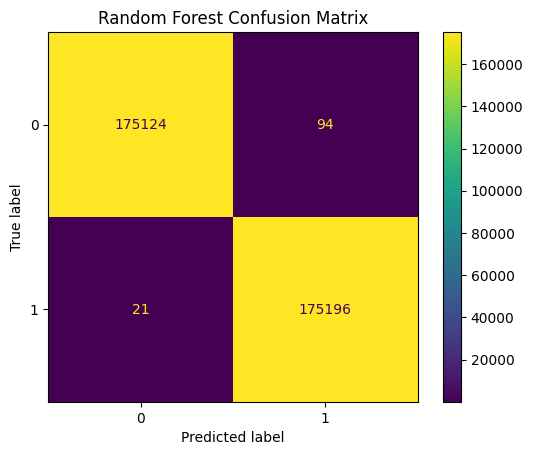

In [ ]:
# Confusion matrix

cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
#KNN

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
print('KNN Accuracy:', accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.9995034742534279
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       1.00      1.00      1.00    175217

    accuracy                           1.00    350435
   macro avg       1.00      1.00      1.00    350435
weighted avg       1.00      1.00      1.00    350435



In [ ]:
# SVM

svm = SVC()
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
print('SVM Accuracy:', accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.9993665016336839
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    175218
           1       1.00      1.00      1.00    175217

    accuracy                           1.00    350435
   macro avg       1.00      1.00      1.00    350435
weighted avg       1.00      1.00      1.00    350435



In [ ]:
# Model comparison

results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','KNN','SVM'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.998807
1,Decision Tree,0.999589
2,Random Forest,0.999672
3,KNN,0.999503
4,SVM,0.999367


In [ ]:
# Cross validation

cv_scores = cross_val_score(rf, X, y, cv=5)

print('Cross Validation Scores:', cv_scores)
print('Average CV Score:', cv_scores.mean())

Cross Validation Scores: [0.99914502 0.99909942 0.99911652 0.99907662 0.99915071]
Average CV Score: 0.9991176561492819


In [ ]:
#Hyperparameter Tuning
# Parameter grid

param_grid = {
    'n_estimators':[50,100],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}

In [ ]:
# GridSearchCV

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='f1')

In [ ]:
# Best parameters

print('Best Parameters:', grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


In [ ]:
# Feature importance

importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

In [ ]:
# Top important features

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
6,hour,0.318408
15,comp_comp2,0.193178
14,comp_comp1,0.148423
17,comp_comp4,0.146959
16,comp_comp3,0.103255
2,rotate,0.016787
3,pressure,0.014904
4,vibration,0.014466
1,volt,0.008932
18,model_model2,0.007020


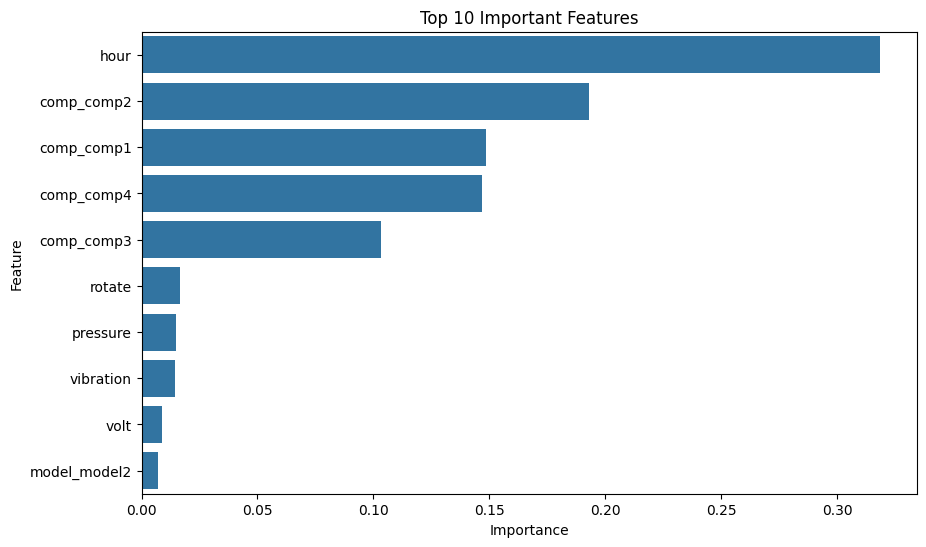

In [ ]:
# Plot feature importance

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title('Top 10 Important Features')
plt.show()

In [ ]:
#PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_train_scaled)

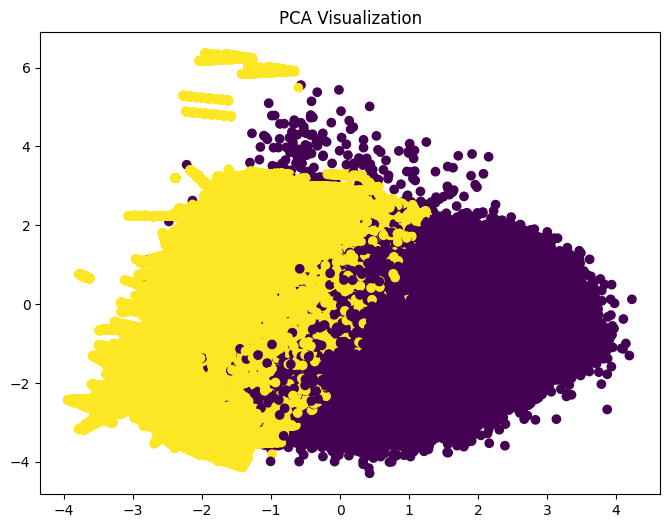

In [ ]:
# PCA visualization

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train)
plt.title('PCA Visualization')
plt.show()

In [ ]:
# MANUAL PREDICTION TESTING
# comparison dataframe

manual_test = X_test.copy()
manual_test['Actual_Failure'] = y_test.values
manual_test['Predicted_Failure'] = rf_pred
manual_test.head(20)

,machineID,volt,rotate,pressure,vibration,age,hour,day,month,errorID_error1,...,errorID_error5,comp_comp1,comp_comp2,comp_comp3,comp_comp4,model_model2,model_model3,model_model4,Actual_Failure,Predicted_Failure
1390843,19,163.890472,416.723789,108.612317,51.908284,13,6,20,1,False,...,False,False,False,False,True,True,False,False,1,1
171947,20,161.708819,489.103479,89.999160,53.201920,16,1,8,8,False,...,False,False,False,False,False,True,False,False,0,0
945183,25,146.515179,409.110193,90.402818,46.710032,18,6,9,6,False,...,False,False,True,False,False,False,True,False,1,1
997596,34,163.048882,349.784450,122.973977,46.499448,11,6,24,9,False,...,False,False,True,False,False,False,False,True,1,1
687919,79,161.478865,455.504023,90.396026,34.259868,14,10,4,6,False,...,False,False,False,False,False,False,True,False,0,0
412439,48,171.712606,461.329806,113.698763,42.356153,10,11,6,1,False,...,False,False,False,False,False,False,False,True,0,0
153553,18,178.350344,508.110074,112.091421,45.731645,15,13,3,7,False,...,False,False,False,False,False,False,True,False,0,0
1361441,9,184.316753,273.644352,101.819482,40.629993,15,6,7,4,False,...,False,False,True,False,False,False,True,False,1,1
1262365,77,190.671371,474.868047,107.693743,41.554761,10,6,27,8,False,...,False,True,False,True,False,True,True,False,1,1
1708740,14,168.383254,480.338502,88.401816,36.325069,11,6,3,5,False,...,False,True,False,False,False,False,True,False,1,1


In [ ]:
# Correctly predicted failures

correct_failures = manual_test[
    (manual_test['Actual_Failure'] == 1) &
    (manual_test['Predicted_Failure'] == 1)
]

correct_failures.head(20)

,machineID,volt,rotate,pressure,vibration,age,hour,day,month,errorID_error1,...,errorID_error5,comp_comp1,comp_comp2,comp_comp3,comp_comp4,model_model2,model_model3,model_model4,Actual_Failure,Predicted_Failure
1390843,19,163.890472,416.723789,108.612317,51.908284,13,6,20,1,False,...,False,False,False,False,True,True,False,False,1,1
945183,25,146.515179,409.110193,90.402818,46.710032,18,6,9,6,False,...,False,False,True,False,False,False,True,False,1,1
997596,34,163.048882,349.784450,122.973977,46.499448,11,6,24,9,False,...,False,False,True,False,False,False,False,True,1,1
1361441,9,184.316753,273.644352,101.819482,40.629993,15,6,7,4,False,...,False,False,True,False,False,False,True,False,1,1
1262365,77,190.671371,474.868047,107.693743,41.554761,10,6,27,8,False,...,False,True,False,True,False,True,True,False,1,1
1708740,14,168.383254,480.338502,88.401816,36.325069,11,6,3,5,False,...,False,True,False,False,False,False,True,False,1,1
1394766,54,197.047957,593.790459,99.902522,43.907565,7,6,9,4,False,...,False,True,False,False,False,False,True,True,1,1
1229796,15,192.123832,341.645824,95.253206,40.719261,14,6,19,1,False,...,False,False,True,False,True,False,True,False,1,1
1057152,20,151.065043,354.919931,97.749350,40.292380,16,6,8,5,False,...,False,False,True,True,False,True,False,False,1,1
895215,94,170.275679,443.836357,124.873629,34.595095,18,6,18,9,False,...,False,False,False,True,False,True,False,False,1,1


In [ ]:
# Missed failures

missed_failures = manual_test[
    (manual_test['Actual_Failure'] == 1) &
    (manual_test['Predicted_Failure'] == 0)
]

missed_failures.head(20)

,machineID,volt,rotate,pressure,vibration,age,hour,day,month,errorID_error1,...,errorID_error5,comp_comp1,comp_comp2,comp_comp3,comp_comp4,model_model2,model_model3,model_model4,Actual_Failure,Predicted_Failure
859691,99,173.235663,453.152821,129.723362,44.624581,14,3,2,1,False,...,False,False,False,False,False,False,False,False,1,0
184254,22,204.623416,426.794399,119.485200,44.055151,14,3,2,1,False,...,False,False,False,False,False,False,False,False,1,0
71667,9,172.514519,382.500782,79.088061,37.589493,7,6,4,3,False,...,False,False,False,True,False,False,False,True,1,0
561399,64,190.820355,495.747474,105.052513,47.237444,20,6,31,12,False,...,False,False,False,True,False,False,True,False,1,0
140393,17,158.098828,406.325391,97.001765,59.967174,14,3,2,1,False,...,False,False,False,False,False,False,False,False,1,0
286507,33,161.068443,503.440728,90.306828,44.999506,14,6,29,8,False,...,False,False,False,True,False,False,True,False,1,0
710078,81,163.635378,346.146866,99.544863,40.612359,1,6,13,12,False,...,False,False,False,True,False,False,False,True,1,0
56077,7,184.217378,427.750822,94.335787,40.380572,20,6,24,5,False,...,False,False,False,True,False,False,True,False,1,0
166136,19,175.579951,477.458648,95.843198,41.961206,17,6,9,12,False,...,False,True,False,False,False,False,True,False,1,0
754423,87,196.411509,437.275230,84.726119,45.292660,12,3,2,1,False,...,False,False,False,False,False,True,False,False,1,0


In [ ]:
# False alarms

false_alarms = manual_test[
    (manual_test['Actual_Failure'] == 0) &
    (manual_test['Predicted_Failure'] == 1)
]

false_alarms.head(20)

,machineID,volt,rotate,pressure,vibration,age,hour,day,month,errorID_error1,...,errorID_error5,comp_comp1,comp_comp2,comp_comp3,comp_comp4,model_model2,model_model3,model_model4,Actual_Failure,Predicted_Failure
316260,37,171.485485,445.823369,110.648512,41.664797,16,6,19,1,False,...,False,False,True,False,False,False,False,False,0,1
655411,75,192.394503,467.119823,120.561974,47.310272,19,6,19,9,False,...,False,False,False,False,True,False,True,False,0,1
667639,77,187.959479,451.455932,100.261755,45.007571,12,6,10,2,False,...,False,False,True,False,False,False,False,True,0,1
843751,97,178.796457,263.722840,101.241001,37.630373,14,6,10,3,False,...,False,True,False,False,False,True,False,False,0,1
714428,82,184.444027,399.722013,114.295631,43.422977,11,6,12,6,False,...,False,False,False,False,True,False,True,False,0,1
195990,23,171.218435,352.591067,102.321073,46.233817,17,6,5,5,False,...,False,True,False,False,False,False,False,False,0,1
167843,20,170.816859,518.075992,95.436111,33.964972,16,6,18,2,False,...,False,False,False,True,False,True,False,False,0,1
258932,30,143.813472,350.334180,105.162257,46.518120,20,6,8,7,False,...,False,False,True,False,False,False,True,False,0,1
816692,94,176.471259,461.832585,104.556964,44.040901,18,6,7,2,False,...,False,True,False,False,False,True,False,False,0,1
182477,21,188.345870,408.812300,99.403644,36.505409,14,6,20,10,False,...,False,True,False,False,False,True,False,False,0,1


In [ ]:
# Check important sensor columns

manual_test[[
    'volt',
    'rotate',
    'pressure',
    'vibration',
    'Actual_Failure',
    'Predicted_Failure'
]].head(30)

,volt,rotate,pressure,vibration,Actual_Failure,Predicted_Failure
1390843,163.890472,416.723789,108.612317,51.908284,1,1
171947,161.708819,489.103479,89.999160,53.201920,0,0
945183,146.515179,409.110193,90.402818,46.710032,1,1
997596,163.048882,349.784450,122.973977,46.499448,1,1
687919,161.478865,455.504023,90.396026,34.259868,0,0
412439,171.712606,461.329806,113.698763,42.356153,0,0
153553,178.350344,508.110074,112.091421,45.731645,0,0
1361441,184.316753,273.644352,101.819482,40.629993,1,1
1262365,190.671371,474.868047,107.693743,41.554761,1,1
1708740,168.383254,480.338502,88.401816,36.325069,1,1


In [ ]:
# High vibration records

high_vibration = manual_test[
    manual_test['vibration'] > 50
]

high_vibration[[
    'vibration',
    'pressure',
    'volt',
    'Actual_Failure',
    'Predicted_Failure'
]].head(20)

,vibration,pressure,volt,Actual_Failure,Predicted_Failure
1390843,51.908284,108.612317,163.890472,1,1
171947,53.201920,89.999160,161.708819,0,0
1270504,57.892918,86.283915,178.524227,1,1
1599351,52.679668,84.404296,175.826554,1,1
923806,59.853777,107.268873,179.093558,1,1
1651084,53.137435,88.014149,166.126831,1,1
1337762,51.230019,110.339144,142.888489,1,1
1047012,52.642559,106.038071,146.175281,1,1
1401449,53.455385,101.978120,160.264906,1,1
130116,58.305771,85.554875,153.886158,0,0


In [ ]:
# High pressure records

high_pressure = manual_test[
    manual_test['pressure'] > 120
]

high_pressure[[
    'pressure',
    'vibration',
    'volt',
    'Actual_Failure',
    'Predicted_Failure'
]].head(20)

,pressure,vibration,volt,Actual_Failure,Predicted_Failure
997596,122.973977,46.499448,163.048882,1,1
400948,120.170585,39.317835,176.419225,0,0
895215,124.873629,34.595095,170.275679,1,1
1236165,124.342272,47.155727,174.727511,1,1
1301936,168.992513,45.009065,201.190185,1,1
193209,120.702712,54.090658,151.165398,0,0
1346486,122.853670,47.007955,175.670094,1,1
1027834,127.151209,35.798222,170.654949,1,1
285019,127.416806,37.287857,179.821180,0,0
1208770,130.142687,34.776616,160.527503,1,1


In [ ]:
# Random samples for manual checking

manual_test.sample(20)

,machineID,volt,rotate,pressure,vibration,age,hour,day,month,errorID_error1,...,errorID_error5,comp_comp1,comp_comp2,comp_comp3,comp_comp4,model_model2,model_model3,model_model4,Actual_Failure,Predicted_Failure
1217013,44,182.719868,391.386342,89.707039,43.908104,6,6,29,6,False,...,False,True,True,False,False,False,False,True,1,1
1515771,67,195.978115,464.584350,95.088941,41.558303,13,6,18,7,False,...,False,True,False,False,True,False,True,True,1,1
1644015,58,178.817083,440.772940,127.404989,38.284092,5,6,29,6,False,...,False,False,True,True,False,False,False,False,1,1
1679640,15,171.526716,327.030222,126.045967,37.429836,3,6,27,10,False,...,False,False,True,False,False,False,False,True,1,1
759633,87,182.330768,431.176026,109.817257,32.644395,12,0,7,8,False,...,False,False,False,False,False,True,False,False,0,0
1391211,92,196.058536,441.111678,96.815057,43.437522,2,6,2,9,False,...,False,True,True,False,False,False,False,False,1,1
1402931,42,170.179928,457.909474,114.548490,49.631187,14,6,30,8,False,...,False,False,False,False,True,False,True,True,1,1
327331,38,184.373661,443.489660,93.344744,46.888514,15,22,24,4,False,...,False,False,False,False,False,False,False,True,0,0
223907,26,163.427350,425.264170,104.236503,43.729489,3,19,10,7,False,...,False,False,False,False,False,False,True,False,0,0
1272674,18,182.105811,479.738557,100.264093,37.606518,4,6,13,4,False,...,False,False,True,True,False,False,True,False,1,1


In [ ]:
# Select one record

single_record = X_test.iloc[[0]]

# Predict

single_prediction = rf.predict(single_record)
print(single_prediction)

[1]


In [ ]:
print("Actual Value :", y_test.iloc[0])
print("Predicted Value :", single_prediction[0])
if single_prediction[0] == 1:
    print("Machine Failure Predicted")
else:
    print("No Machine Failure Predicted")

Actual Value : 1
Predicted Value : 1
Machine Failure Predicted
